In [2]:
import VMBQC_functions
from VMBQC_functions import *

In [3]:
torch.cuda.is_available()

True

In [13]:
# Hyperparameters for the learning model

samples=8000 # Total number of samples 

qubits=7

depth=4

layers=depth

##  Learning models

In [8]:
# Here, the unitary model is the only learning model

dev = qml.device("default.qubit", wires=qubits,shots=samples)

@qml.qnode(dev)
def eqv_circ_st(params):  
    
    p=params[:int(len(params)/2)] # probabilities
    
    t=params[len(p):] # thetas
    
    # Design of the fully corrected CQCA
    
    [qml.Hadamard(wires=q) for q in range(qubits)]
    

    for l in range(depth): 
        
        
        for q in range(qubits):
            qml.RZ(t[qubits*l+q],wires=q)
            
       
            
        
        for q in range(qubits):
            if q<qubits-1:
                qml.CZ(wires=[q,q+1])
        qml.CZ(wires=[0,qubits-1])  

        for q in range(qubits):
            qml.Hadamard(wires=q)

    
    return qml.sample()

In [7]:
def sample_circ(par):
    
    binary_array = np.array(eqv_circ_st(par))
    powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
    decimal_array = np.sum(binary_array * powers_of_two, axis=1)
    decimal_list = decimal_array.tolist()
    
    return decimal_list


# Testing the analytical result in vmbqc paper

Keep the $\theta$s fixed as in other cases and see the effect of the $p_c$s by chaning its position manually

In [7]:
t2=np.array([0.25346914, 0.87569937, 0.45982243, 0.2101851 , 0.86541588,
        0.41781881, 0.75031244, 0.54803307, 0.38187175, 0.80987642,
        0.58446993, 0.3905621 , 0.10959787, 0.89544531, 0.03546959,
        0.86318735, 0.35996152, 0.63933876, 0.92219972, 0.15170662,
        0.56695048, 0.76443286, 0.75758383, 0.52563191, 0.62473946,
        0.75752699, 0.84102764, 0.7618131 ])

In [8]:
t2

tensor([0.25346914, 0.87569937, 0.45982243, 0.2101851 , 0.86541588,
        0.41781881, 0.75031244, 0.54803307, 0.38187175, 0.80987642,
        0.58446993, 0.3905621 , 0.10959787, 0.89544531, 0.03546959,
        0.86318735, 0.35996152, 0.63933876, 0.92219972, 0.15170662,
        0.56695048, 0.76443286, 0.75758383, 0.52563191, 0.62473946,
        0.75752699, 0.84102764, 0.7618131 ], requires_grad=True)

In [9]:
# Sampling a single correction probability, this works typically at P\in [0.1,0.2], one can go close to zero, but then the qubit becomes completely random

k=[3+qubits] #range(qubits)
p2=np.ones((qubits*depth))
p2[k]=0.13540049 #np.random.uniform(.1,.5,len(k))
p2

tensor([1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        0.13540049, 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        ], requires_grad=True)

## Description of the target model

Here, the model from which the target distribution is generated is provided in Eq. 15 in the paper. In this model the code works using 

In [10]:
# Hyperparameters for the target model

# Pennylane devices have inbuild command names "shots" which is number of samples for a specific circuit architecture
N=10 # number of "shots"

# Total number of samples from MBQC-CQCA (includes the "shots" for each circuit with different byproducts)
target_samples = 20000 
runs=int(target_samples/N) # Number of times our model should run (at each of this "runs", the specific pennylane circuit provides N=10 "shots" / target_samples)

qubits=7
depth=4
layers=depth

In [6]:
# Initiating model \tilde{\epsilon}_c with the hyperparameters given in Eq. 15
model=VMBQC(qubits,layers,N)

/home/arun/.local/lib/python3.10/site-packages/pennylane/numpy/tensor.py:155: RuntimeWarning: divide by zero encountered in divide
  res = super().__array_ufunc__(ufunc, method, *args, **kwargs)


7.470121622085571 sec


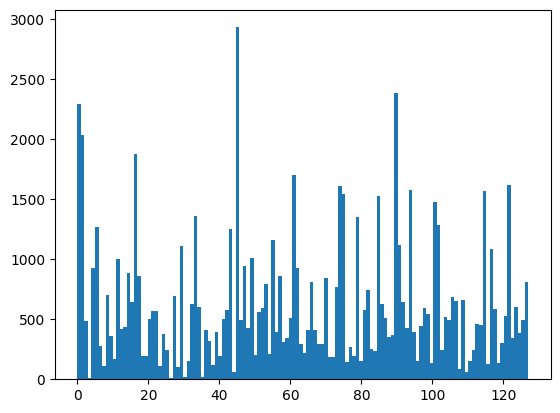

In [11]:
# # function to get a single (1) (or, N = shots) number of data sample(s) from a single run of CQCA with given correction probabilities (p)
def get_samples_jl(runs, params):
    arr=[]
    p=params[:qubits*depth] #np.repeat(params[:1],qubits*depth) # cause you only have one probability parameter

    t=params[len(p):] 
    
    arr.append(model.corrected_machine_f2(p,t))
    return np.concatenate(arr)


# To generate the target distribution 

# # function to get m (e.g. "runs=20000/10=2000") number of data samples from our model
def target_circuit(init_para):  
    
    results = Parallel(n_jobs = 30)(delayed(get_samples_jl)(r, init_para) for r in range(target_samples))
    s_a=list(itertools.chain.from_iterable(results))
    binary_array = np.array(s_a)
    #print(binary_array)
    powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
    decimal_array = np.sum(binary_array * powers_of_two, axis=1)
    decimal_list = decimal_array.tolist()
    
    return decimal_list


init_para= np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)
s=time.time()
f_s_t=plt.hist(target_circuit(init_para),bins=2**qubits)
e=time.time()
print(e-s,'sec')


In [12]:
(init_para)

tensor([        inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
        -1.85402943,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,  0.25346914,  0.87569937,
         0.45982243,  0.2101851 ,  0.86541588,  0.41781881,  0.75031244,
         0.54803307,  0.38187175,  0.80987642,  0.58446993,  0.3905621 ,
         0.10959787,  0.89544531,  0.03546959,  0.86318735,  0.35996152,
         0.63933876,  0.92219972,  0.15170662,  0.56695048,  0.76443286,
         0.75758383,  0.52563191,  0.62473946,  0.75752699,  0.84102764,
         0.7618131 ], requires_grad=True)

In [13]:
np.savetxt(f'target_param_p_pos:{k}',init_para)
# init_test_p = np.loadtxt(f'new_models/target_param_p_pos:{k}')
# sigmoid(init_test_p[:qubits*depth])

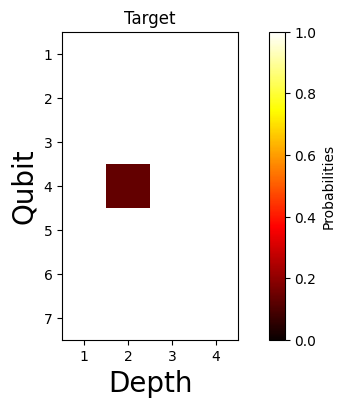

In [14]:
gen_prob_par(sigmoid(init_para[:qubits*depth]),qubits,depth,'Target')

In [15]:
pg=f_s_t[0]/(N*target_samples)
sum(pg)

0.9999999999999998

In [16]:
np.savetxt(f'target_dist_channel_k:{k}',pg)

In [17]:
k

[10]

In [12]:
# sampling from target distribution e.g. mixed gaussian
def sample_target_function():
    x=range(2**qubits)
    ret = np.random.choice(x,samples,p=pg) # here we use 'samples' instead of 'target_samples' becasue in the training phase the # samples from target distribution
                                           # and model distribution should be the same
    return ret.copy()

0.0753929615020752 sec


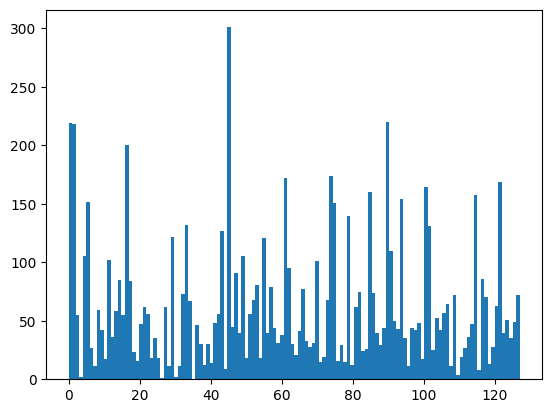

In [19]:
s=time.time()
opt_hist=plt.hist(sample_target_function(),bins=2**qubits)
e=time.time()
print(e-s,'sec')

In [20]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [21]:
# kernel function to calculate distance between two sample data points

def kernel_exp_torch(s1,s2):
    s1t = torch.tensor(s1, dtype = torch.float64).to(DEVICE)
    s2t = torch.tensor(s2, dtype = torch.float64).to(DEVICE)
    d1 = s1t.size(-1)
    d2 = s2t.size(-1)
    s1t = s1t.reshape([1,-1,1])
    s2t = s2t.reshape([1,-1,1])
    
    diffsquared = (torch.cdist(s1t,s2t,p=2.0).to(DEVICE))**2

    sigma_list=[0.5,4]
    exp = 0.0
    for sigma in sigma_list:
        expMatrix = torch.exp(diffsquared/(-2.0*sigma)).to(DEVICE)
        expMatrix = expMatrix/(len(sigma_list)*d1*d2)
        exp = exp + torch.sum(expMatrix).to(DEVICE)
        
    return exp

In [22]:
def mmd_loss(params):
    
    s2=sample_target_function()
    s1=sample_circ(params)
    res=kernel_exp_torch(s1,s1)-2*kernel_exp_torch(s1,s2)+kernel_exp_torch(s2,s2)
    return res.detach().cpu().numpy()


In [23]:
torch.repeat_interleave(torch.zeros(1),10)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [24]:
# Gradient for correction probabilities stated in eq. 17 of: https://arxiv.org/pdf/2310.13524.pdf

def mmd_grad_p_new(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    grad = torch.zeros(len(p)).to(DEVICE)
    
    
    
    sample_targ=sample_target_function()
    
    for i in range(len(p)):
        
        sample_y = sample_circ(params) ###############  eqv_circ_st(params)
        
        a=p[i].copy()
        inner_derivative = (sigmoid(torch.tensor(a))**2)*torch.exp(-torch.tensor(a))
        
        p[i]=torch.tensor(100.0).numpy()
        
        sample_x_1 = sample_circ(params) ###############  eqv_circ_st(params)
       
        
        p[i]=torch.tensor(-100.0).numpy()
        
        sample_x_0 = sample_circ(params) ###############  eqv_circ_st(params)
        
        
        grad[i]=2*(kernel_exp_torch(sample_y,sample_x_1)-kernel_exp_torch(sample_y,sample_x_0)) - 2*(kernel_exp_torch(sample_targ,sample_x_1)-kernel_exp_torch(sample_targ,sample_x_0))
        grad[i]= grad[i]*inner_derivative
        p[i]=a
        #if i == 0:
        #    print(params[:int(len(params)/2)])

        
    return grad


def mmd_grad_1layer_p_new(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    # grad = torch.zeros(len(p)).to(DEVICE)
    grad_1 = torch.zeros(len(p)).to(DEVICE)

    
    d=1
    for pr,i in zip(p,range(qubits*d)): # as you have only N prob that repeats across the first layer

        if pr!=torch.inf:
            
            sample_targ=sample_target_function()
            sample_y = sample_circ(params) ###############  eqv_circ_st(params)
            
            a=p[i].copy()
            inner_derivative = (sigmoid(torch.tensor(a))**2)*torch.exp(-torch.tensor(a))
            
            p[i]=torch.tensor(100.0).numpy()
            
            sample_x_1 = sample_circ(params) ###############  eqv_circ_st(params)
           
            
            p[i]=torch.tensor(-100.0).numpy()
            
            sample_x_0 = sample_circ(params) ###############  eqv_circ_st(params)
            
            
            grad_1[i]=2*(kernel_exp_torch(sample_y,sample_x_1)-kernel_exp_torch(sample_y,sample_x_0)) - 2*(kernel_exp_torch(sample_targ,sample_x_1)-kernel_exp_torch(sample_targ,sample_x_0))
            grad_1[i]= grad_1[i]*inner_derivative
            p[i]=a
        #if i == 0:
        #    print(params[:int(len(params)/2)])
        
    # grad_1=torch.concatenate([grad_1,torch.zeros(depth*(qubits-d)).to(DEVICE)])

        
    return grad_1
    
    
# Gradient for variational parameters \thetas stated in eq. 16 of: https://arxiv.org/pdf/2310.13524.pdf
    
def mmd_grad_theta(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    prob = sample_circ(params)
    grad = torch.zeros(len(thetas)).to(DEVICE)
    
    for i in range(len(thetas)):
        # pi/2 phase
        thetas[i] += np.pi/2.
        prob_pos = sample_circ(params) # p_{theta}^{+}
        # -pi/2 phase
        thetas[i] -= np.pi
        prob_neg = sample_circ(params) # p_{theta}^{-}
        
        t1=kernel_exp_torch(prob, prob_pos)
        
        t2=kernel_exp_torch(prob, prob_neg)

        t3=kernel_exp_torch(sample_target_function(), prob_pos)
        
        t4=kernel_exp_torch(sample_target_function(), prob_neg)

        
        grad_pos = t1 - t2
        grad_neg = t3 - t4
        grad[i] = (grad_pos - grad_neg).detach().cpu()
        
        thetas[i] += np.pi/2.0 #reset to original value
        
    return grad


# combined gradient of both sets of parameters

def mmd_grad(params):
    #probs=params[:int(len(params)/2)]
    #thetas=params[len(probs):]
    grad=torch.cat((mmd_grad_1layer_p_new(params),mmd_grad_theta(params)))
    return grad

In [25]:
'''
import torch
import gc
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
            print(obj.shape, type(obj), obj.size(), obj.device)
    except:
        pass
'''

"\nimport torch\nimport gc\nfor obj in gc.get_objects():\n    try:\n        if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):\n            print(obj.shape, type(obj), obj.size(), obj.device)\n    except:\n        pass\n"

In [26]:
#torch.cuda.empty_cache()

In [27]:
#import gc

#gc.collect()
#torch.cuda.empty_cache()


In [28]:
# algorithm for gradient descent copied from : https://docs.pennylane.ai/en/stable/code/api/pennylane.GradientDescentOptimizer.html

# We rewrote the algorithm with our approximate gradient calculated from samples instead of using the in-built exact gradient 

class GradientDescentOptimizer_mmd_2:  
    def __init__(self, stepsize): # if some value is given here itself then it will become a by default value
        self.stepsize = stepsize

    def step_and_cost(self, objective_fn, *args, grad_fn=None, **kwargs):
        
        g, forward = self.compute_grad(objective_fn, args, kwargs, grad_fn=grad_fn)
        new_args = self.apply_grad(g, args)

        if forward is None:
            forward = objective_fn(*args, **kwargs)

        # unwrap from list if one argument, cleaner return
        if len(new_args) == 1:
            return new_args[0], forward
        return new_args, forward


    def step(self, objective_fn, *args, train, grad_fn=None, **kwargs):
        
        p_len=int(len(args[0])/2)
        if train=='p':
            arg1=args[0][:int(len(args[0])/2)]
        else:
            arg1=args[0][int(len(args[0])/2):]
        
        g= self.compute_grad(objective_fn, args, kwargs, grad_fn=grad_fn)
        new_args = self.apply_grad(g, arg1,args,train)

        # unwrap from list if one argument, cleaner return
        if len(new_args) == 1:
            return new_args[0]

        return new_args

    @staticmethod
    def compute_grad(objective_fn, args, kwargs, grad_fn=None):
       
        
        grad = mmd_grad(*args).detach().cpu().numpy()
        

        num_trainable_args = sum(getattr(arg, "requires_grad", False) for arg in args)
        grad = (grad,) if num_trainable_args == 1 else grad
        #print('grads--',grad[0])
        return grad


    def apply_grad(self, grad, arg1,args,train):
        
        #print('arg1--',arg1)#################
        args_new = list(arg1)
        
        if train=='p':

            trained_index = 0
            for index, arg in enumerate(arg1):

                if getattr(arg, "requires_grad", False):
                    args_new[index] = arg - self.stepsize * grad[0][trained_index]

                    trained_index += 1
        else:
            trained_index = p_len ########## need to be generalized
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    args_new[index] = arg - self.stepsize * grad[0][trained_index]

                    trained_index += 1
            
        
        #print('new args-->',args_new[0])#############
        
        if train=='p':
            return np.concatenate([args_new,args[0][len(args_new):]])
        else:
            return np.concatenate([args[0][:len(args_new)],args_new]) # here we can do this only because the they have same size
        

In [29]:
# We use parts the above above algorithm to finally use the Adagrad optimization algorithm below to update our tunable parameters

from pennylane.numpy import sqrt
class AdagradOptimizer_mmd_2(GradientDescentOptimizer_mmd_2):
    

    def __init__(self, stepsize=0.01, eps=1e-8):
        super().__init__(stepsize)
        self.eps = eps
        self.accumulation = None

    def apply_grad(self, grad, arg1, args, train):
        
        p_len=int(len(args[0])/2)
        args_new = list(arg1)

        if self.accumulation is None:
            self.accumulation = [0.0] * len(arg1)
            
        if train=='p':

            trained_index = 0
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    

                    self._update_accumulation(index, grad[0][trained_index])

                    coeff = self.stepsize / sqrt(self.accumulation[index] + self.eps)
                    args_new[index] = arg - coeff * grad[0][trained_index]

                    trained_index += 1
                    
        else:
            
            trained_index = p_len # need to be generalized
            
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    

                    self._update_accumulation(index, grad[0][trained_index])

                    coeff = self.stepsize / sqrt(self.accumulation[index] + self.eps)
                    args_new[index] = arg - coeff * grad[0][trained_index]

                    trained_index += 1
            
            

        if train=='p':
            return np.concatenate([args_new,args[0][len(args_new):]])
        else:
            return np.concatenate([args[0][:len(args_new)],args_new])


    def _update_accumulation(self, index, grad):
        
        self.accumulation[index] = self.accumulation[index] + grad**2

    def reset(self):
        
        self.accumulation = None

In [30]:
def cost(par):

    c=mmd_loss(par) 
    return c

In [31]:
cost(init_para)

array(0.00281087)

In [32]:
k

[10]

In [34]:
runs_2=10
iterations=199  # next time if run the same experiment for more agents then iterations=199


## seeding 
import random
import os

# Set seed for reproducibility (before any random ops)
seed = 42
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
####### end of seeding


cost_arr=[]
params_arr=[]
for r in range(runs_2):
    # opt1 = AdagradOptimizer_mmd_2(stepsize=0.2)
    opt2 = AdagradOptimizer_mmd_2(stepsize=0.1)
    
   
    
    p2=np.ones((qubits*depth)) # The training model is unitary so no need of correction probs and hence set them to one
    # p2[k]=np.random.uniform(.89,.95,len(k))
    t2=np.random.uniform(0,1,qubits*depth)
    init_p=np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)

    params=init_p
    
    cost_arr.append(cost(init_p))
    params_arr.append(init_p)
    

    current_cost=[]
    
    for i in range(iterations):


        start=time.time()
        # params = opt1.step(cost, params,train='p')
        params = opt2.step(cost, params,train='t')
        end=time.time()
        current_cost.append(cost(params))
        cost_arr.append(current_cost[i])
        

        params_arr.append(params)
        #params_arr_tot_2.append(params)

        if i % 1 == 0:
            print(f"Cost at step {i}:", current_cost[i],f'of run:{r}')

            
            print('time taken-->',(end-start)/60,'min')

    
    np.savetxt(f'{k}_qubit_target_unit_learningmodel_depth:{depth}_loss_{r}.txt', cost_arr)
    np.savetxt(f'{k}_qubit_target_unit_learningmodel_depth:{depth}_par_{r}.txt', params_arr)

Cost at step 0: 0.008530538495888723 of run:0
time taken--> 0.09301974376042683 min
Cost at step 1: 0.007636561611649054 of run:0
time taken--> 0.08895351886749267 min
Cost at step 2: 0.006383845938174905 of run:0
time taken--> 0.09069954951604207 min
Cost at step 3: 0.0058274340458501946 of run:0
time taken--> 0.09031359752019247 min
Cost at step 4: 0.006015749958239936 of run:0
time taken--> 0.09066133896509807 min
Cost at step 5: 0.005251227479582003 of run:0
time taken--> 0.09089796543121338 min
Cost at step 6: 0.0050039423955490145 of run:0
time taken--> 0.08979270855585735 min
Cost at step 7: 0.005044853758326088 of run:0
time taken--> 0.09074349403381347 min
Cost at step 8: 0.004595287222508328 of run:0
time taken--> 0.09083381493886312 min
Cost at step 9: 0.00491657224849925 of run:0
time taken--> 0.0920012871424357 min
Cost at step 10: 0.0044179476932244485 of run:0
time taken--> 0.08944878180821737 min
Cost at step 11: 0.004158447826357905 of run:0
time taken--> 0.09037816921

In [35]:
min(cost_arr)

array(0.00058745)

In [5]:
c_t = np.loadtxt(f'{k}_qubit_target_unit_learningmodel_depth:{depth}_loss_{9}.txt')
c_t.min()

tensor(0.00095554, requires_grad=True)

In [84]:
k

[10]

In [221]:
cost_arr.index(min(cost_arr))

1497

In [224]:
opt_p=(params_arr[cost_arr.index(min(cost_arr))])
opt_p

tensor([       inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf, 0.41043698, 1.19323198,
        0.4719778 , 0.21179684, 0.24888134, 0.3346625 , 0.15308643,
        0.62616949, 0.44979806, 1.00411547, 0.33727742, 1.16711395,
        0.57124307, 0.45941024, 0.12771878, 0.85397231, 0.43093883,
        0.31507237, 0.31932199, 0.35847714, 0.49861533, 0.08417051,
        0.34963947, 0.4276187 , 0.38157226, 0.36386174, 0.25354522,
        0.82000511], requires_grad=True)

0.06687593460083008 sec


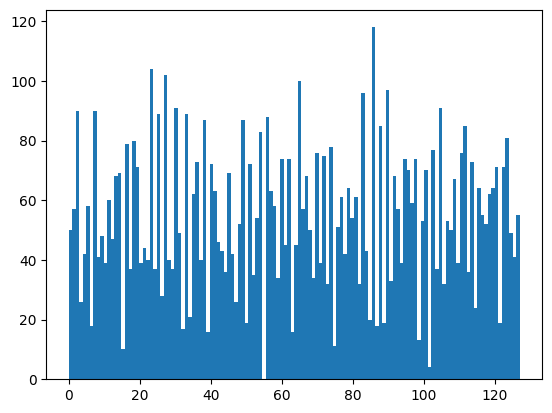

In [99]:
s=time.time()
f_s_t=plt.hist(sample_circ(opt_p),bins=2**qubits)
e=time.time()
print(e-s,'sec')

In [14]:
p_t=np.loadtxt(f'new_models/qubitwise_target/{k}_qubit_p_target_etilde_learningmodel_par_{0}.txt')
sigmoid(p_t[-1])

NameError: name 'k' is not defined

In [15]:
from matplotlib.animation import FuncAnimation, PillowWriter


def load_and_reshape(txt_file):
    arr = sigmoid(np.loadtxt(txt_file)[:, :qubits * depth])
    if arr.ndim != 2 or arr.shape[1] != depth*qubits:
        raise ValueError("Expected (n_frames, 56) shape")
    # Reshape to (frames, rows=7, cols=8) — which matches your arr.reshape(-1,7,8)
    return arr.reshape(-1, depth, qubits)

def animate_grid(frames, output=f'new_models/p_evol_plots/{k}_qubit_p_target_etilde_learningmodel.gif', fps=10, cmap='hot'):
    n_frames, rows, cols = frames.shape  # rows=7, cols=8
    fig, ax = plt.subplots()
    
    # Transpose the first frame for correct axes orientation
    im = ax.imshow(frames[0].T,
                   vmin=frames.min(), vmax=frames.max(),
                   cmap=cmap, aspect='auto')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Probabilities')
    ax.set_title(f'Frame 1/{n_frames}')
    ax.set_xlabel('Depth')
    ax.set_ylabel('Qubit')

    def update(i):
        im.set_data(frames[i].T)  # Transpose each frame before plotting
        ax.set_title(f'Evolution of probs at epoch {i+1}/{n_frames}')
        return (im,)

    anim = FuncAnimation(fig, update, frames=n_frames,
                         interval=1000/fps, blit=True)
    writer = PillowWriter(fps=fps)
    anim.save(output, writer=writer)
    plt.close(fig)
    print(f"✅ GIF saved as '{output}'")

if __name__ == "__main__":
    data3d = load_and_reshape(f'new_models/qubitwise_target/{k}_qubit_p_target_etilde_learningmodel_par_{0}.txt'
                             )
    animate_grid(data3d, fps=10)

NameError: name 'k' is not defined

In [16]:
np.savetxt(f'unit_5q_etilde_layer_{k}_1_p_target_loss.txt', cost_arr)
np.savetxt(f'unit_5q_etilde_layer_{k}_1_p_target_par.txt', params_arr)

NameError: name 'k' is not defined

In [17]:
par_model = np.loadtxt(f'etilde_5q_etilde_all_same_p_target_par_{4}.txt')

FileNotFoundError: etilde_5q_etilde_all_same_p_target_par_4.txt not found.

In [18]:
sigmoid(params_arr[-1])

NameError: name 'params_arr' is not defined

In [19]:
gen_prob_par(par_model[-1][:qubits*depth],qubits,depth)

NameError: name 'par_model' is not defined

In [785]:
cost_channel_target = np.loadtxt(f'new_models/qubitwise_target/{k}_qubit_p_target_unit_learningmodel_loss_{4}.txt')
cost_channel_target.shape

(1000,)

In [799]:
cost_channel_target[:200]

tensor([0.05421503, 0.03850735, 0.02095143, 0.01489375, 0.00952386,
        0.00607734, 0.00429791, 0.005213  , 0.00419301, 0.00458129,
        0.00435567, 0.00365019, 0.00258474, 0.00350518, 0.0026983 ,
        0.00290786, 0.00336054, 0.00256478, 0.00207736, 0.00216366,
        0.00240381, 0.00286678, 0.00244549, 0.00198848, 0.00195944,
        0.00223772, 0.00177095, 0.00234615, 0.00207199, 0.00236809,
        0.00173223, 0.00174109, 0.00204599, 0.00149069, 0.00200329,
        0.00171619, 0.00195475, 0.00187765, 0.00203812, 0.00168964,
        0.00162466, 0.00178552, 0.00184245, 0.00217061, 0.00182756,
        0.00202922, 0.00168082, 0.00135248, 0.00186408, 0.00258813,
        0.00228841, 0.00175759, 0.00238944, 0.001282  , 0.00155067,
        0.00151754, 0.00193157, 0.00177404, 0.0017899 , 0.00121984,
        0.0018081 , 0.0020455 , 0.00202657, 0.00187043, 0.00151638,
        0.00153833, 0.00156621, 0.00237812, 0.00218911, 0.00127614,
        0.00207027, 0.00120094, 0.00137075, 0.00

In [794]:
cost_channel_target.min()

tensor(0.00066775, requires_grad=True)

In [795]:
cost_unit_target = np.loadtxt(f'new_models/qubitwise_target/unit_target_unit_learningmodel_loss_{4}.txt')
cost_unit_target.min()

tensor(0.00046734, requires_grad=True)

In [800]:
cost_unit_target[:200]

tensor([0.11200129, 0.07922287, 0.06322121, 0.04795331, 0.03363409,
        0.02371302, 0.01735112, 0.01285907, 0.00914898, 0.00534169,
        0.00430852, 0.00468036, 0.00283431, 0.0033728 , 0.00301447,
        0.00264991, 0.00275133, 0.00221101, 0.00158484, 0.00193348,
        0.00205514, 0.00310071, 0.00203717, 0.00195564, 0.00160935,
        0.00160951, 0.00108001, 0.00185753, 0.00215449, 0.00130635,
        0.00128562, 0.00121872, 0.00100867, 0.00185412, 0.00142701,
        0.00122438, 0.00167464, 0.00154832, 0.00145519, 0.00186811,
        0.00155284, 0.00146982, 0.00179954, 0.00216424, 0.00147452,
        0.00117127, 0.00135013, 0.0014096 , 0.00153836, 0.00146082,
        0.00140576, 0.00135788, 0.00100152, 0.00108709, 0.00122515,
        0.001154  , 0.00093558, 0.00103369, 0.00165848, 0.00106538,
        0.00190281, 0.00099547, 0.00109051, 0.00105161, 0.00097979,
        0.00134383, 0.0012657 , 0.00087991, 0.00090483, 0.00080105,
        0.00119594, 0.00134895, 0.00121688, 0.00

In [272]:

import gc

mmd_grad(params).cpu()
del mmd_grad
gc.collect()
torch.cuda.empty_cache()
